In [12]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from lime.lime_text import LimeTextExplainer
import shap

In [13]:
data = [
    ("Free entry in 2 a wkly competition to win FA Cup final tickets", 1),
    ("URGENT! You have won a 1 week FREE membership in our prize draw", 1),
    ("Win cash now by clicking this exclusive offer", 1),
    ("Claim your free reward today", 1),
    ("Congratulations, you have been selected for a gift voucher", 1),
    ("Call now to receive your prize", 1),
    ("Are we still meeting tomorrow morning?", 0),
    ("Please send me the report before 5pm", 0),
    ("Can you join the team meeting this afternoon?", 0),
    ("I will call you later after class", 0),
    ("Lunch at 12 with the project group?", 0),
    ("Dont forget to bring your notebook to school", 0),
]

df = pd.DataFrame(data, columns=["text", "label"])
df["label_name"] = df["label"].map({0: "ham", 1: "spam"})

df

,text,label,label_name
0,Free entry in 2 a wkly competition to win FA C...,1,spam
1,URGENT! You have won a 1 week FREE membership ...,1,spam
2,Win cash now by clicking this exclusive offer,1,spam
3,Claim your free reward today,1,spam
4,"Congratulations, you have been selected for a ...",1,spam
5,Call now to receive your prize,1,spam
6,Are we still meeting tomorrow morning?,0,ham
7,Please send me the report before 5pm,0,ham
8,Can you join the team meeting this afternoon?,0,ham
9,I will call you later after class,0,ham


In [14]:

vectorizer = TfidfVectorizer(lowercase=True, stop_words="english")
X = vectorizer.fit_transform(df["text"])
y = df["label"]

print("Shape TF-IDF:", X.shape)
print("Số từ trong vocabulary:", len(vectorizer.vocabulary_))

Shape TF-IDF: (12, 47)
Số từ trong vocabulary: 47


In [15]:
nb_model = MultinomialNB()
nb_model.fit(X, y)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X, y)

nb_pred = nb_model.predict(X)
lr_pred = lr_model.predict(X)

print("Naive Bayes accuracy:", accuracy_score(y, nb_pred))
print("Logistic Regression accuracy:", accuracy_score(y, lr_pred))

Naive Bayes accuracy: 1.0
Logistic Regression accuracy: 1.0


In [16]:
test_email = "Free cash prize waiting for you, call now"
test_vec = vectorizer.transform([test_email])

nb_proba = nb_model.predict_proba(test_vec)[0]
lr_proba = lr_model.predict_proba(test_vec)[0]

print("Test email:", test_email)
print("NB prediction:", "spam" if nb_model.predict(test_vec)[0] == 1 else "ham", nb_proba)
print("LR prediction:", "spam" if lr_model.predict(test_vec)[0] == 1 else "ham", lr_proba)

Test email: Free cash prize waiting for you, call now
NB prediction: spam [0.28640228 0.71359772]
LR prediction: spam [0.37893621 0.62106379]


In [17]:
class_names = ["ham", "spam"]
explainer = LimeTextExplainer(class_names=class_names)

def predict_proba_lime(texts):
    vec = vectorizer.transform(texts)
    return nb_model.predict_proba(vec)

lime_exp = explainer.explain_instance(
    test_email,
    predict_proba_lime,
    num_features=10
)

lime_exp.as_list()

[(np.str_('prize'), 0.0743556984589984),
 (np.str_('Free'), 0.06989814578768833),
 (np.str_('cash'), 0.01368808209279184),
 (np.str_('for'), 0.001776972822126175),
 (np.str_('call'), 0.0011087726811253949),
 (np.str_('waiting'), 0.0010545452889364852),
 (np.str_('now'), 0.0008857262749726415),
 (np.str_('you'), 0.0008595337948346368)]

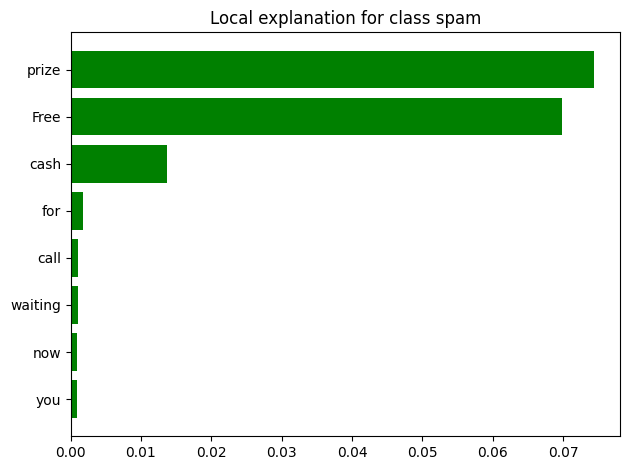

In [18]:
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

In [19]:
X_dense = X.toarray()
feature_names = vectorizer.get_feature_names_out()

shap_explainer = shap.Explainer(lr_model, X_dense, feature_names=feature_names)
shap_values = shap_explainer(X_dense)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (12, 47)


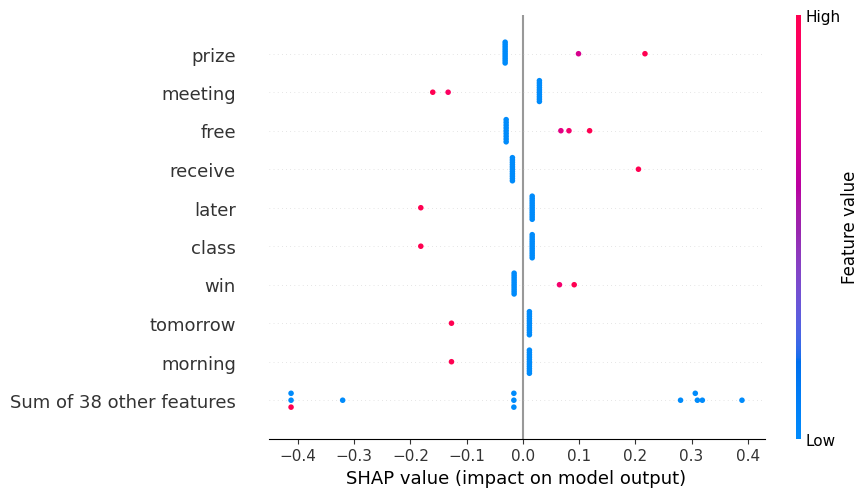

In [20]:
shap.plots.beeswarm(shap_values, max_display=10)

In [21]:
coef = lr_model.coef_[0]

importance_df = pd.DataFrame({
    "word": feature_names,
    "coef": coef
}).sort_values("coef", ascending=False)

print("Top từ đẩy về spam:")
display(importance_df.head(10))

print("Top từ đẩy về ham:")
display(importance_df.tail(10).sort_values("coef", ascending=True))

Top từ đẩy về spam:


,word,coef
29,prize,0.381808
18,free,0.370054
31,receive,0.295553
44,win,0.270860
5,claim,0.205819
39,today,0.205819
33,reward,0.205819
35,selected,0.202909
19,gift,0.202909
9,congratulations,0.202909


Top từ đẩy về ham:


,word,coef
24,meeting,-0.365539
6,class,-0.280281
22,later,-0.280281
26,morning,-0.229349
40,tomorrow,-0.229349
32,report,-0.228848
36,send,-0.228848
1,5pm,-0.228848
23,lunch,-0.198189
0,12,-0.198189


In [22]:
print("KẾT LUẬN TUẦN 1")
print("- Đã tạo pipeline TF-IDF + Naive Bayes / Logistic Regression")
print("- Đã dùng LIME để giải thích 1 email cụ thể")
print("- Đã dùng SHAP để xem mức độ quan trọng của từ")
print("- Có thể dùng kết quả này để chuẩn bị tích hợp vào app ở tuần 3")

KẾT LUẬN TUẦN 1
- Đã tạo pipeline TF-IDF + Naive Bayes / Logistic Regression
- Đã dùng LIME để giải thích 1 email cụ thể
- Đã dùng SHAP để xem mức độ quan trọng của từ
- Có thể dùng kết quả này để chuẩn bị tích hợp vào app ở tuần 3
